In [2]:
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
# Dataset tips — restauracja, 244 rachunki
tips = sns.load_dataset('tips')
# Dane sprzedaży TechShop (z W08)
miesiace = ['Sty', 'Lut', 'Mar', 'Kwi', 'Maj', 'Cze']
sprzedaz_2024 = [45230, 38920, 52100, 48700, 55200, 62300]
sprzedaz_2023 = [41000, 35000, 48000, 44000, 50000, 58000]
kategorie = ['Komputery', 'Akcesoria', 'Audio', 'Storage']
sprzedaz_kat = [15899.94, 2939.83, 1199.97, 349.93]
print(f"Tips dataset: {tips.shape}")
print(tips.head(3))



Tips dataset: (244, 7)
   total_bill   tip     sex smoker  day    time  size
0       16.99  1.01  Female     No  Sun  Dinner     2
1       10.34  1.66    Male     No  Sun  Dinner     3
2       21.01  3.50    Male     No  Sun  Dinner     3


In [3]:
fig, ax = plt.subplots(figsize=(6, 3))
ax.plot([1, 2, 3], [1, 4, 2])

print(f"Typ fig: {type(fig).__name__}")
print(f"Typ ax:  {type(ax).__name__}")
print(f"\nfig.get_size_inches(): {fig.get_size_inches()}")    # rozmiar w calach
print(f"ax.get_xlim():         {ax.get_xlim()}")                # zakres osi X
print(f"ax.get_ylim():         {ax.get_ylim()}")                # zakres osi Y

plt.close()

Typ fig: Figure
Typ ax:  Axes

fig.get_size_inches(): [6. 3.]
ax.get_xlim():         (np.float64(0.9), np.float64(3.1))
ax.get_ylim():         (np.float64(0.85), np.float64(4.15))


# Ćwiczenie 1: Podstawowe typy wykresów — linia, słupki, scatter

## Zadanie 1.1 — Wykres liniowy: trend sprzedaży

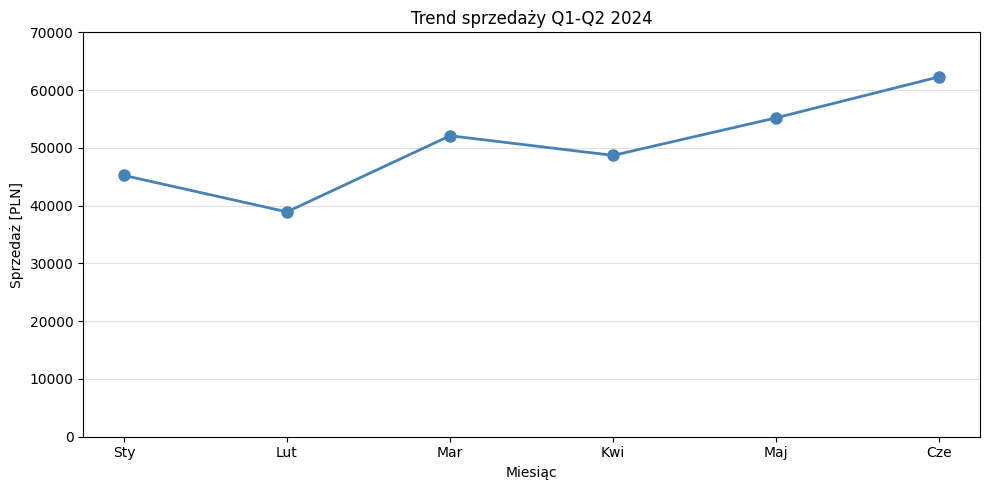

Zapisano: trend_2024.png


In [4]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(miesiace, sprzedaz_2024,
 color='steelblue',
 linewidth=2,
 marker='o',
 markersize=8)
ax.set_title('Trend sprzedaży Q1-Q2 2024')
ax.set_xlabel('Miesiąc')
ax.set_ylabel('Sprzedaż [PLN]')
ax.set_ylim(0, 70000)
ax.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.savefig('trend_2024.png', dpi=100)
plt.show()
plt.close()
print("Zapisano: trend_2024.png")

## Zadanie 1.2 — Wykres słupkowy: sprzedaż per kategoria

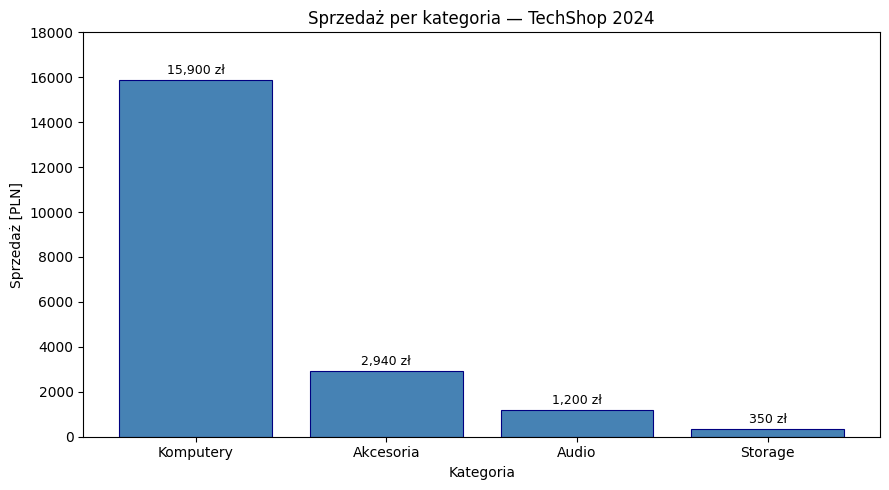

Zapisano: sprzedaz_kategorie.png


In [6]:
fig, ax = plt.subplots(figsize=(9, 5))
slupki = ax.bar(kategorie, sprzedaz_kat,
 color='steelblue',
 edgecolor='navy',
 linewidth=0.8)
# Dodaj wartości nad słupkami
for slupek, wartosc in zip(slupki, sprzedaz_kat):
 ax.text(
 slupek.get_x() + slupek.get_width() / 2, # środek słupka w osi X
 slupek.get_height() + 126, # ile JEDNOSTEK osi Y nad słupkiem? (~0.7% zakresu)
 f'{wartosc:,.0f} zł', # format: 11,899 zł
 ha='center', va='bottom', fontsize=9 # wyrównanie poziome — środek
 )
ax.set_title('Sprzedaż per kategoria — TechShop 2024')
ax.set_xlabel('Kategoria')
ax.set_ylabel('Sprzedaż [PLN]')
ax.set_ylim(0, 18000)
plt.tight_layout()
plt.savefig('sprzedaz_kategorie.png', dpi=100)
plt.show()
plt.close()
print("Zapisano: sprzedaz_kategorie.png")

## Zadanie 1.3 — Scatter: rachunek vs napiwek (tips dataset)


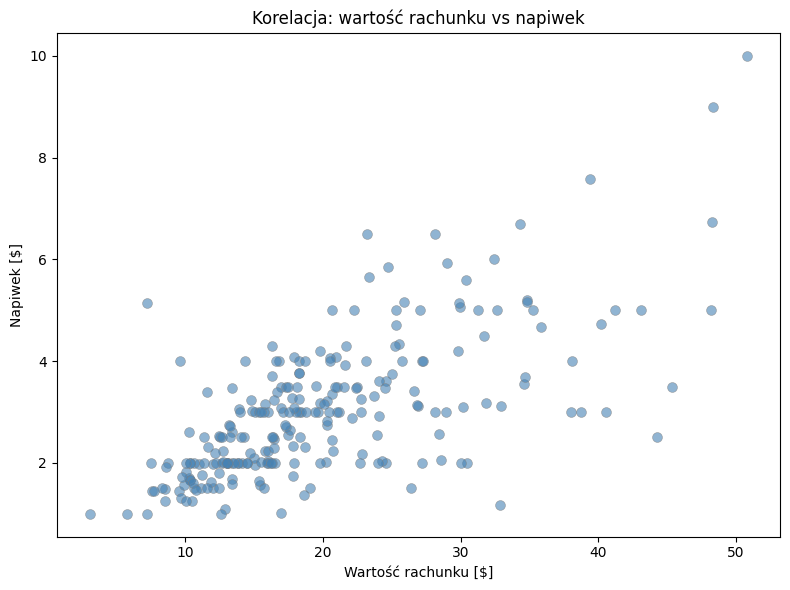

Zapisano: scatter_tips.png


In [7]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(tips['total_bill'], tips['tip'],
 alpha=0.6,
 color='steelblue',
 s=50, 
 edgecolors='gray',
 linewidth=0.5
)
ax.set_title('Korelacja: wartość rachunku vs napiwek')
ax.set_xlabel('Wartość rachunku [$]')
ax.set_ylabel('Napiwek [$]')
plt.tight_layout()
plt.savefig('scatter_tips.png', dpi=100)
plt.show()
plt.close()
print("Zapisano: scatter_tips.png")

## wyzwanie dodatkowe
Dodaj do scatter z 1.3 kolorowanie według liczby gości (tips['size']) używając parametru
c=tips['size'], cmap='Blues'. 

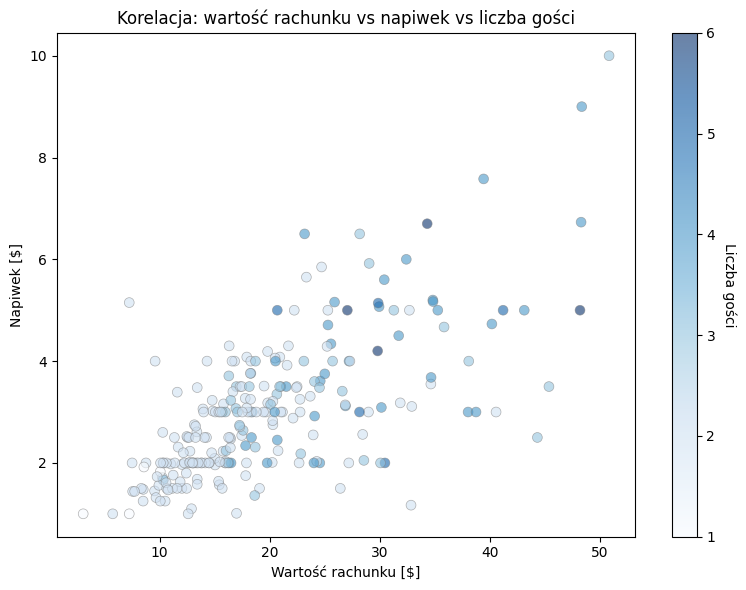

Zapisano: scatter_tips2.png


In [11]:
fig, ax = plt.subplots(figsize=(8, 6))

scatter = ax.scatter(
    tips['total_bill'], tips['tip'],
    c=tips['size'],
    cmap='Blues',
    alpha=0.6,
    s=50, 
    edgecolors='gray',
    linewidth=0.5
)
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Liczba gości', rotation=270, labelpad=15)
ax.set_title('Korelacja: wartość rachunku vs napiwek vs liczba gości')
ax.set_xlabel('Wartość rachunku [$]')
ax.set_ylabel('Napiwek [$]')
plt.tight_layout()
plt.savefig('scatter_tips2.png', dpi=100)
plt.show()
plt.close()
print("Zapisano: scatter_tips2.png")

# Ćwiczenie 2: Dostosowywanie — etykiety, kolory, legendy 
## Zadanie 2.1 — Porównanie dwóch lat (legenda)


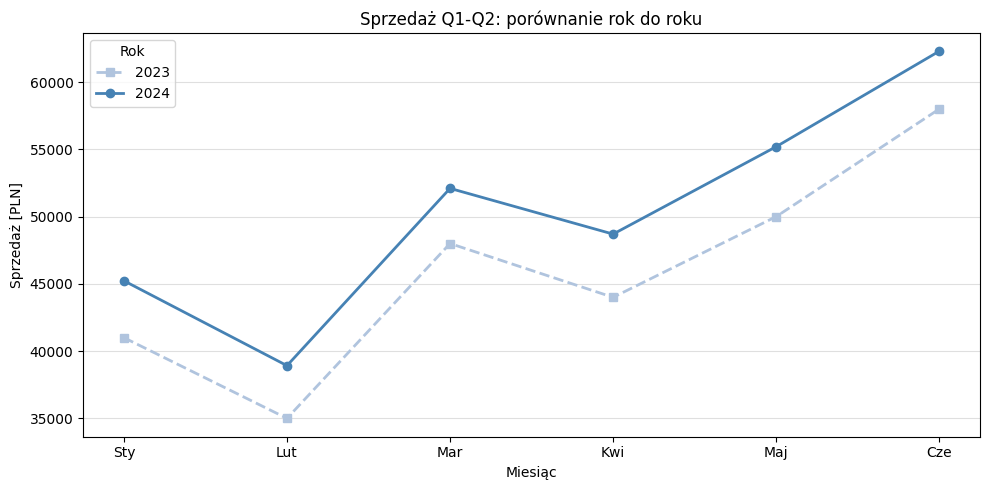

Zapisano: porownanie_lat.png


In [3]:
fig, ax = plt.subplots(figsize=(10, 5))
# Seria 2023 — linia przerywana
ax.plot(miesiace, sprzedaz_2023,
 label='2023',
 color='lightsteelblue',
 linewidth=2,
 marker='s', 
 linestyle='--') 
# Seria 2024 — linia ciągła
ax.plot(miesiace, sprzedaz_2024,
 label='2024',
 color='steelblue',
 linewidth=2,
 marker='o')
ax.set_title('Sprzedaż Q1-Q2: porównanie rok do roku')
ax.set_xlabel('Miesiąc')
ax.set_ylabel('Sprzedaż [PLN]')
ax.legend(title='Rok', loc='upper left') 
ax.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.savefig('porownanie_lat.png', dpi=100)
plt.show()
plt.close()
print("Zapisano: porownanie_lat.png")

## Zadanie 2.2 — Słupki poziome z kolorami (barh)
Narysuj słupki poziome sprzedaży per kategoria. Każdy słupek innym kolorem.


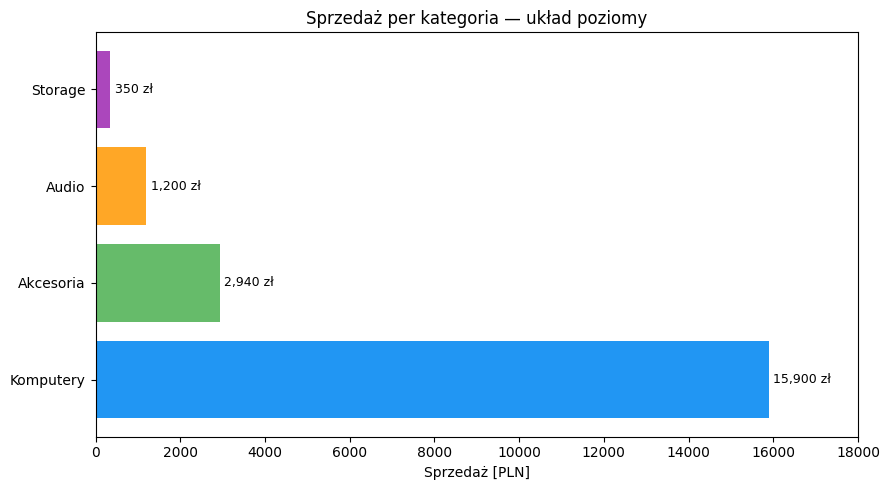

Zapisano: kategorie_poziome.png


In [9]:
kolory_kat = ['#2196F3', '#66BB6A', '#FFA726', '#AB47BC']

fig, ax = plt.subplots(figsize=(9,5))

ax.barh(kategorie,sprzedaz_kat,
    color=kolory_kat
)
# Etykiety wartości przy słupkach
for i, (kat, wartosc) in enumerate(zip(kategorie, sprzedaz_kat)):
    ax.text(wartosc + 100, i,
    f'{wartosc:,.0f} zł',
    va='center', fontsize=9)

ax.set_title('Sprzedaż per kategoria — układ poziomy')
ax.set_xlabel('Sprzedaż [PLN]')
ax.set_xlim(0, 18000)
plt.tight_layout()
plt.savefig('kategorie_poziome.png', dpi=100)
plt.show()
plt.close()
print("Zapisano: kategorie_poziome.png")

## Zadanie 2.3 — Styl wykresów

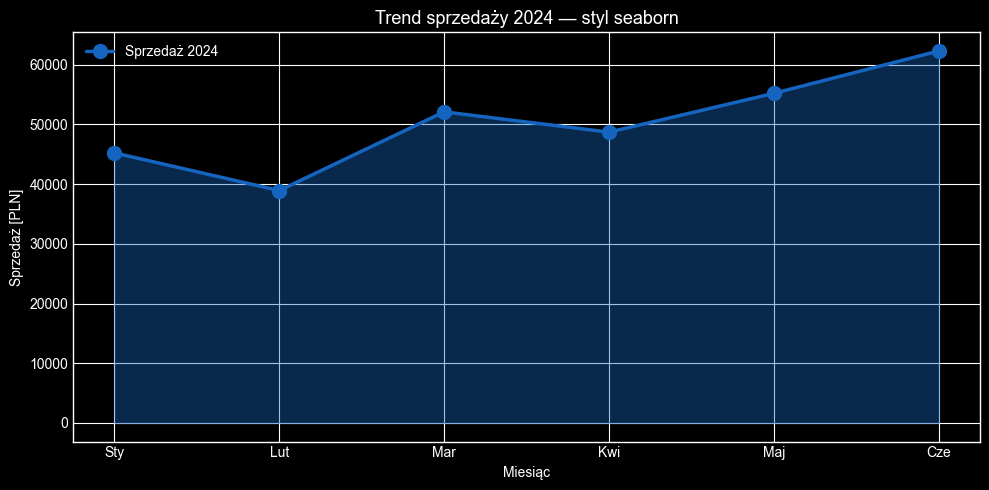

Zapisano: trend_styl.png


In [12]:
#plt.style.use('seaborn-v0_8-whitegrid')
plt.style.use('dark_background')

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(miesiace, sprzedaz_2024,
 color='#1565C0',
 linewidth=2.5,
 marker='o',
 markersize=10,
 label='Sprzedaż 2024')

ax.fill_between(miesiace, sprzedaz_2024,
 alpha=0.4, 
 color='#1565C0') 

ax.set_title('Trend sprzedaży 2024 — styl seaborn', fontsize=13)
ax.set_xlabel('Miesiąc')
ax.set_ylabel('Sprzedaż [PLN]')
ax.legend()
plt.tight_layout()
#plt.savefig('trend_styl.png', dpi=100)
plt.show()
plt.close()

plt.style.use('default')
print("Zapisano: trend_styl.png")

# Ćwiczenie 3: Pełna wizualizacja z datasetu tips

## Zadanie 3.1 — Kiedy klienci zostawiają najwyższe napiwki?
Oblicz średni napiwek per dzień tygodnia i narysuj wykres słupkowy.


day
Thur    2.77
Fri     2.73
Sat     2.99
Sun     3.26
Name: tip, dtype: float64


ValueError: shape mismatch: objects cannot be broadcast to a single shape.  Mismatch is between arg 0 with shape (244,) and arg 1 with shape (4,).

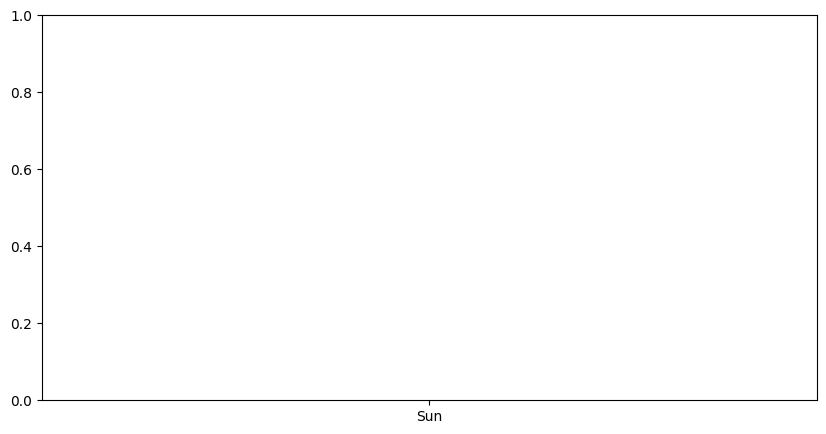

In [23]:
średni_napiwek = tips.groupby('day')['tip'].mean().round(2)
print(średni_napiwek)
fig, ax = plt.subplots(figsize=(10,5))

slupki = ax.bar(tips['day'] ,średni_napiwek,
    color='steelblue',
    edgecolor='navy',
    linewidth=0.8
)

for slupek, wartosc in zip(slupki, średni_napiwek):
    ax.text(
        slupek.get_x() + slupek.get_width() / 2, 
        slupek.get_height() + 100,
        f'{wartosc:,.0f} zł',
        ha='center', va='bottom', fontsize=9 
    )
ax.set_title('Średni napiwek per dzień tygodnia')
ax.set_xlabel('Dni tygodnia')
ax.set_ylabel('Średni napiwek')
ax.set_ylim(0,10)
plt.tight_layout()
plt.show()
plt.close()

## Zadanie 3.2 — Czy palacze dają wyższe napiwki?
Narysuj scatter: total_bill vs tip, z kolorowaniem według kolumny smoker (Tak/Nie).

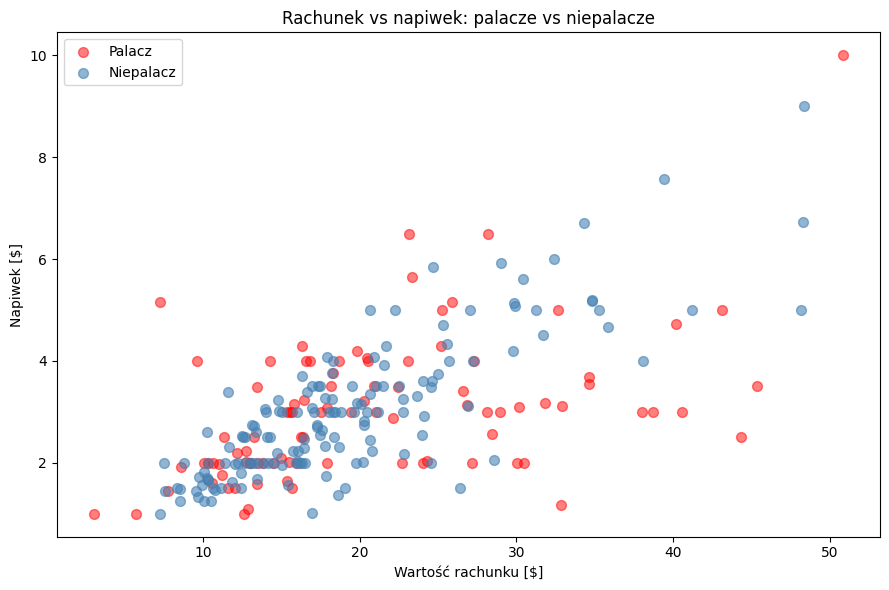

Zapisano: scatter_palacze.png


In [25]:
fig, ax = plt.subplots(figsize=(9, 6))
# Podziel na dwie grupy i narysuj osobno
palacze = tips[tips['smoker'] == 'Yes']
niepalacze = tips[tips['smoker'] == 'No']
ax.scatter(palacze['total_bill'], palacze['tip'],
    alpha=0.5,
    color='red',
    label='Palacz',
    s=50)
ax.scatter(niepalacze['total_bill'], niepalacze['tip'], 
    alpha=0.6,
    color='steelblue',
    label='Niepalacz',
    s=50)

ax.set_title('Rachunek vs napiwek: palacze vs niepalacze')
ax.set_xlabel('Wartość rachunku [$]')
ax.set_ylabel('Napiwek [$]')
ax.legend()
plt.tight_layout()
plt.savefig('scatter_palacze.png', dpi=100)
plt.show()
plt.close()
print("Zapisano: scatter_palacze.png")


## Zadanie 3.3 — Rozkład napiwków (histogram + obserwacja)

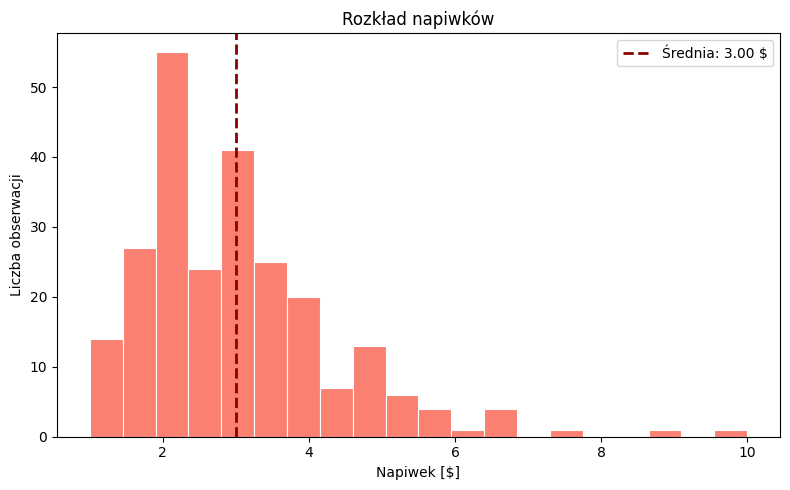

Zapisano: histogram_napiwki.png


In [30]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(tips['tip'],
 bins=20, # spróbuj 10, 20, 30 — który najczytelniej?
 color='salmon',
 edgecolor='white',
 linewidth=0.8)
ax.set_title('Rozkład napiwków')
ax.set_xlabel('Napiwek [$]')
ax.set_ylabel('Liczba obserwacji')

# Dodaj pionową linię — średnia
ax.axvline(tips['tip'].mean(),
 color='darkred',
 linewidth=2,
 linestyle='--',
 label=f"Średnia: {tips['tip'].mean():.2f} $")
ax.legend()
plt.tight_layout()
plt.savefig('histogram_napiwki.png', dpi=100)
plt.show()
plt.close()
print("Zapisano: histogram_napiwki.png")

## Zadanie 3.4 — Słupkowy: liczba zamówień per pora dnia

sex     Male  Female
time                
Lunch     33      35
Dinner   124      52


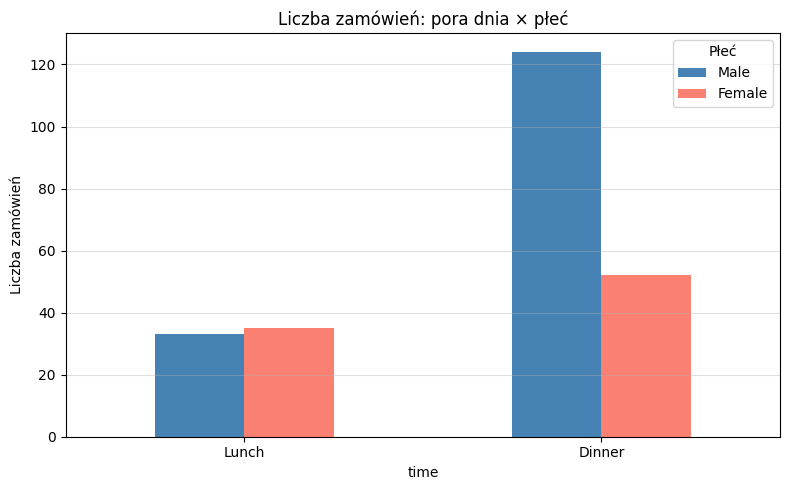

Zapisano: zamowienia_pora.png


In [31]:
# Zlicz zamówienia per pora dnia i płeć
count_df = tips.groupby(['time', 'sex'], observed=True)['total_bill'].count().unstack()
print(count_df)
# Wykres słupkowy grupowany — pora dnia w wierszach, płeć w kolumnach
ax = count_df.plot(
 kind='bar',
 figsize=(8, 5),
 color=['steelblue', 'salmon'],
 title='Liczba zamówień: pora dnia × płeć',
 ylabel='Liczba zamówień',
 rot=0
)
ax.legend(title='Płeć')
ax.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.savefig('zamowienia_pora.png', dpi=100)
plt.show()
plt.close()
print("Zapisano: zamowienia_pora.png")

## wnioski
Z wykresu napiwki/dzień tygodnia wynika że klienci zostawiają najwyższe napiwki w weekendy dlatego nie powinniśmy zmieniać dni otwarcia.<br>

Z wykresu palacz vs napiwki da się wywnioskować że palacze są mniej skłonni do dawania wysokich napiwków możemy dla nich dobudować osobą sekcje restauracji dla palących (widziałem pare takich w wrocławiu)<br>

Rozkład napiwków zachowuje naturalną prawostronność typową dla pieniędzy nie ma tu nic więcej do powiedzenia<br>

Mężczyźni dominują pod względem zamówień w porze obiadowej co zapewne wynika z spotkań służbowych przydatną zmianą byłoby udekorowanie restauracji w sposób bardziej oficjalny aby przyciągnąć tego typu spotkania do nas jeszcze częściej

# Ćwiczenie 4: Wiele wykresów (subplots) + zapis + commit

## Zadanie 4.1 — Dashboard tips 2×2


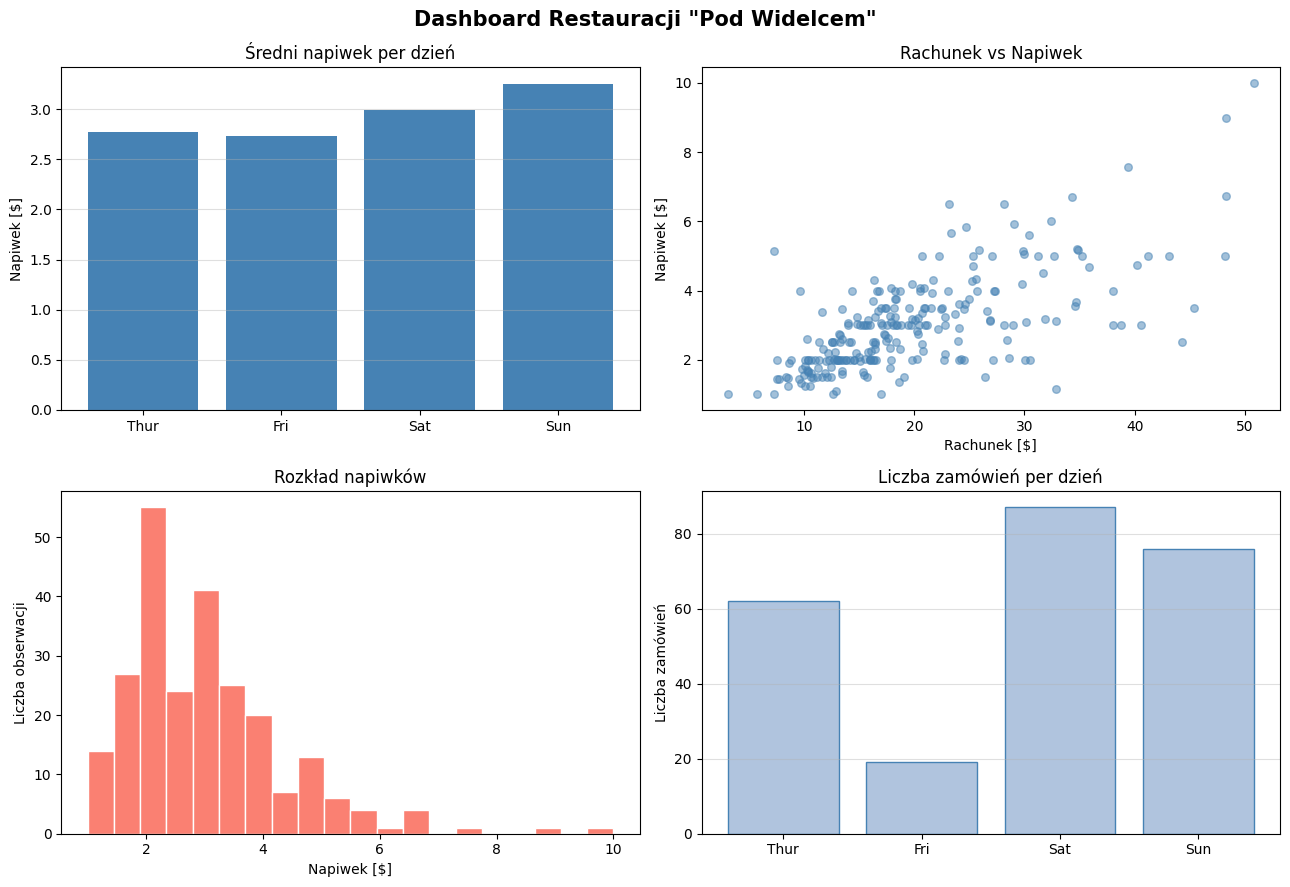

Zapisano: dashboard_tips.png


In [33]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
# [0, 0] — Średni napiwek per dzień (słupkowy)
sredni_napiwek_dzien = tips.groupby('day', observed=True)['tip'].mean()
axes[0, 0].bar(sredni_napiwek_dzien.index,
    sredni_napiwek_dzien.values,
    color='steelblue')
axes[0, 0].set_title('Średni napiwek per dzień')
axes[0, 0].set_ylabel('Napiwek [$]')
axes[0, 0].grid(axis='y', alpha=0.4)
# [0, 1] — Scatter: rachunek vs napiwek
axes[0, 1].scatter(tips['total_bill'], tips['tip'],
 alpha=0.5,
 color='steelblue',
 s=30)
axes[0, 1].set_title('Rachunek vs Napiwek')
axes[0, 1].set_xlabel('Rachunek [$]')
axes[0, 1].set_ylabel('Napiwek [$]')
# [1, 0] — Histogram napiwków
axes[1, 0].hist(tips['tip'],
 bins=20,
 color='salmon',
 edgecolor='white')
axes[1, 0].set_title('Rozkład napiwków')
axes[1, 0].set_xlabel('Napiwek [$]')
axes[1, 0].set_ylabel('Liczba obserwacji')
# [1, 1] — Liczba zamówień per dzień (bar)
zamowienia_dzien = tips.groupby('day', observed=True)['total_bill'].count()
axes[1, 1].bar(zamowienia_dzien.index,
 zamowienia_dzien.values,
 color='lightsteelblue',
 edgecolor='steelblue')
axes[1, 1].set_title('Liczba zamówień per dzień')
axes[1, 1].set_ylabel('Liczba zamówień')
axes[1, 1].grid(axis='y', alpha=0.4)

plt.suptitle('Dashboard Restauracji "Pod Widelcem"',fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('dashboard_tips.png', dpi=100)
plt.show()
plt.close()
print("Zapisano: dashboard_tips.png")